# Order Delay Intelligence Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")

payments = pd.read_csv("Dataset/olist_order_payments_dataset.csv")

customers = pd.read_csv("Dataset/olist_customers_dataset.csv")

items = pd.read_csv("Dataset/olist_order_items_dataset.csv")

products = pd.read_csv("Dataset/olist_products_dataset.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)


In [4]:
print("Orders Dataset")
orders.info()

print("\nCustomers Dataset")
customers.info()

print("\nItems Dataset")
items.info()

Orders Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Customers Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   custome

In [5]:
print("Orders Missing Values")
print(orders.isnull().sum())

print("\nCustomers Missing Values")
print(customers.isnull().sum())

print("\nItems Missing Values")
print(items.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

Orders Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Customers Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Items Missing Values
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products Missing Values
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2

In [6]:
print("Orders Duplicates:", orders.duplicated().sum())

print("Customers Duplicates:", customers.duplicated().sum())

print("Items Duplicates:", items.duplicated().sum())

print("Products Duplicates:", products.duplicated().sum())

Orders Duplicates: 0
Customers Duplicates: 0
Items Duplicates: 0
Products Duplicates: 0


# Dataset Audit Summary

The datasets were successfully loaded and inspected to understand their structure and quality before analysis.

The audit process included:

- Checking dataset dimensions and record counts
- Reviewing column names and data types
- Identifying missing values
- Detecting duplicate records

### Key Findings

- The Orders dataset contains 99,441 records.
- Customer information is complete with no missing values.
- Some delivery-related date columns contain missing values, which is expected for orders that were cancelled or not yet delivered.
- Product-related datasets contain a very small number of missing values.
- No significant duplicate records were found in the primary datasets.

The audit confirms that the datasets are suitable for further cleaning, feature engineering, exploratory data analysis, and machine learning tasks.

In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

print("Date conversion completed")

Date conversion completed


In [8]:
orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
].dtypes

order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object

In [9]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_time_days"
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [10]:
orders["is_delayed"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
).astype(int)

orders["is_delayed"].value_counts()

is_delayed
0    91614
1     7827
Name: count, dtype: int64

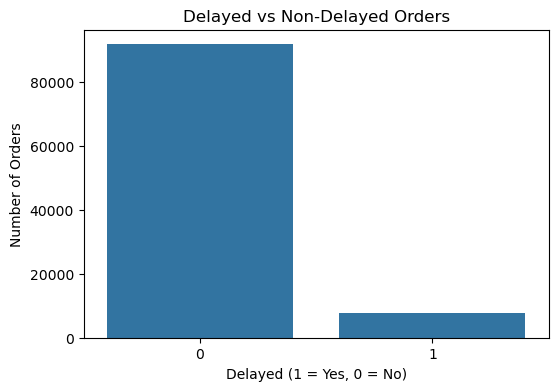

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="is_delayed",
    data=orders
)

plt.title("Delayed vs Non-Delayed Orders")
plt.xlabel("Delayed (1 = Yes, 0 = No)")
plt.ylabel("Number of Orders")

plt.show()

### Insight 1

The majority of orders were delivered on time, while only a small percentage experienced delays.

From the analysis, approximately 91,614 orders were delivered within the estimated delivery period, whereas around 7,827 orders were delayed.

This indicates that the logistics and delivery process performs reliably for most customers. However, delayed orders still represent an important business challenge because they can negatively affect customer satisfaction and overall shopping experience.

Understanding the factors that contribute to delayed deliveries can help improve operational efficiency and support the development of predictive models for delivery delay detection.

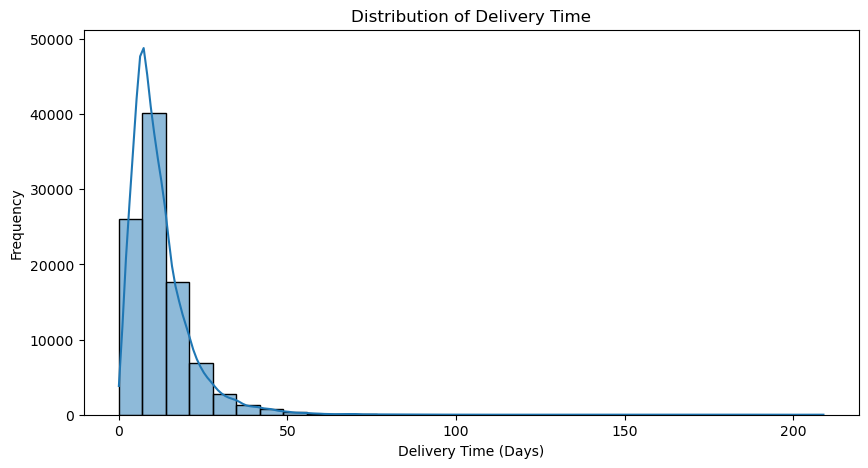

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["delivery_time_days"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")

plt.show()

### Insight 2

Most deliveries are completed within a relatively small number of days, while a smaller group of orders takes significantly longer.

This suggests that most deliveries follow a predictable timeline, but some orders experience unusually long delays.

In [13]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.month
)

orders["purchase_month"].head()

0    10
1     7
2     8
3    11
4     2
Name: purchase_month, dtype: int32

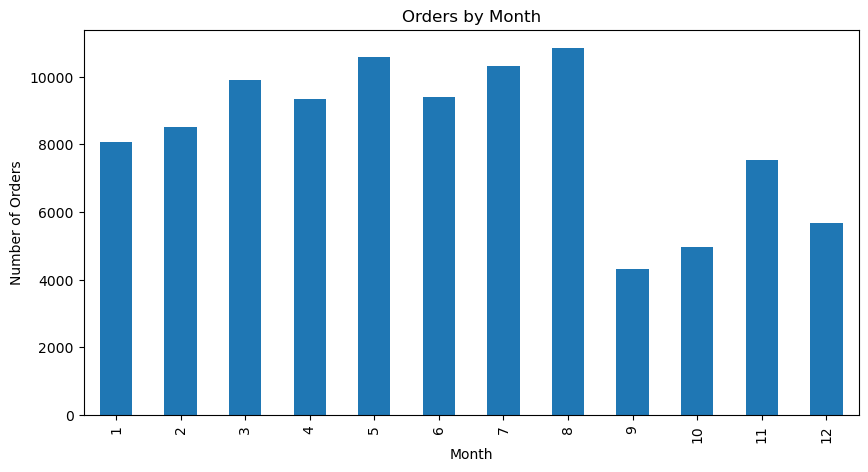

In [14]:
monthly_orders = (
    orders.groupby("purchase_month")
    .size()
)

plt.figure(figsize=(10,5))

monthly_orders.plot(
    kind="bar"
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

### Insight 3

Order volume varies across different months of the year, indicating seasonal purchasing behavior.

Certain months experience higher transaction volumes than others, which may be influenced by holidays, promotional campaigns, or customer shopping patterns.

Understanding monthly demand trends can help businesses improve inventory planning, staffing decisions, and logistics management.

In [15]:
orders["purchase_weekday"] = (
    orders["order_purchase_timestamp"]
    .dt.day_name()
)

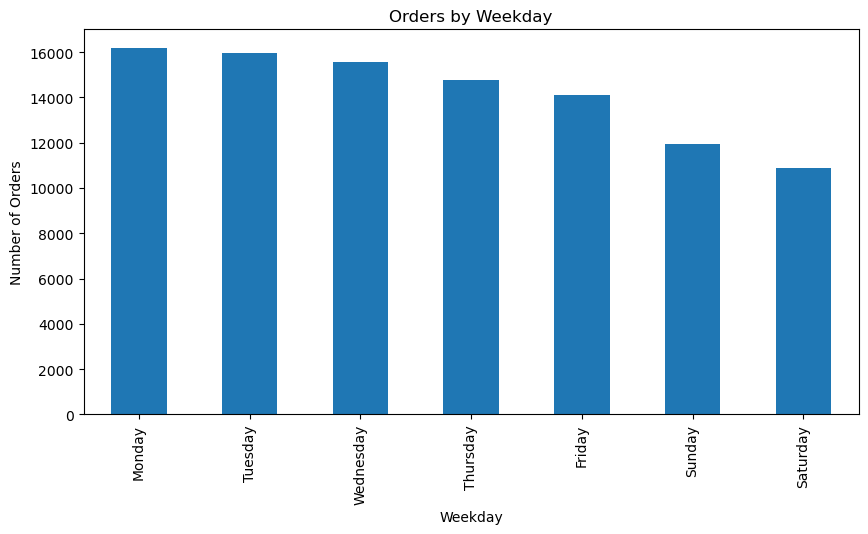

In [16]:
weekday_orders = (
    orders["purchase_weekday"]
    .value_counts()
)

plt.figure(figsize=(10,5))

weekday_orders.plot(
    kind="bar"
)

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")

plt.show()

### Insight 4

Customer purchasing activity differs across weekdays.

Some days attract significantly more orders than others, suggesting that customer shopping behavior follows weekly patterns.

These insights can help businesses schedule marketing campaigns and optimize operational resources during peak shopping days.

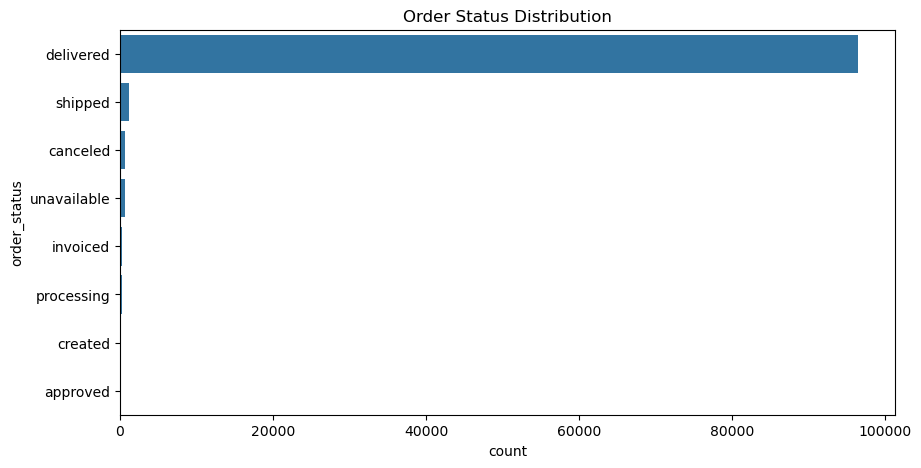

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="order_status",
    data=orders,
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")

plt.show()

### Insight 5

Most orders successfully reach the delivered status, while cancelled, unavailable, and processing orders represent a relatively small portion of total transactions.

This indicates that the order fulfillment process is generally effective, although improving the handling of non-delivered orders could further enhance customer satisfaction.

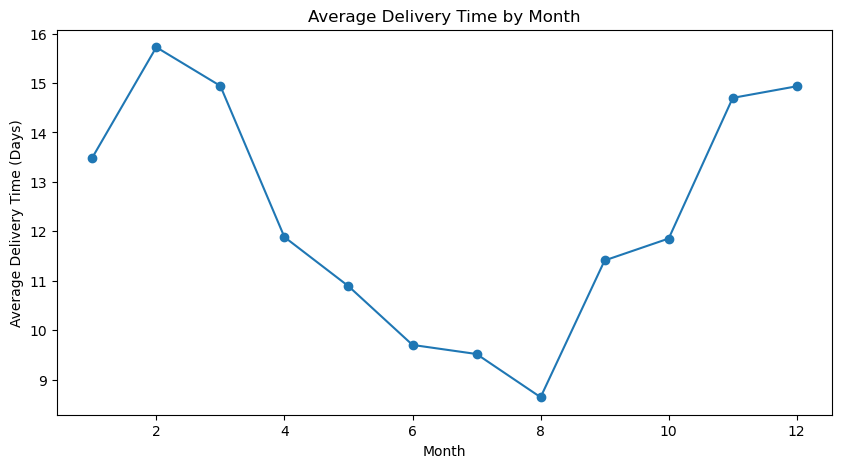

In [18]:
monthly_delivery = (
    orders.groupby("purchase_month")[
        "delivery_time_days"
    ]
    .mean()
)

plt.figure(figsize=(10,5))

monthly_delivery.plot(
    marker="o"
)

plt.title("Average Delivery Time by Month")
plt.xlabel("Month")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

### Insight 6

Average delivery time changes across different months, suggesting that seasonal factors may influence logistics performance.

Periods with longer delivery times may be associated with higher order volumes, transportation constraints, or operational challenges.

Monitoring these trends can help improve delivery planning and customer experience.

# Business Insights Summary

The exploratory data analysis revealed several important business findings:

1. Most orders are delivered on time, while delayed deliveries account for a smaller proportion of transactions.

2. Delivery times are concentrated within a predictable range, although some orders experience unusually long delays.

3. Order volume changes throughout the year, indicating seasonal purchasing patterns.

4. Customer purchasing behavior varies across weekdays.

5. The majority of orders successfully reach the delivered status.

6. Average delivery times fluctuate across months, suggesting seasonal effects on logistics performance.

These insights provide valuable information for understanding customer behavior, delivery efficiency, and factors that may contribute to delayed deliveries.

# SQLite Database Analysis

In [19]:
import sqlite3

In [20]:
conn = sqlite3.connect("order_delay.db")

print("Database Created Successfully")

Database Created Successfully


In [21]:
orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

items.to_sql(
    "items",
    conn,
    if_exists="replace",
    index=False
)

payments.to_sql(
    "payments",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

print("Tables Created Successfully")

Tables Created Successfully


In [22]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders
"""

pd.read_sql(query, conn)

,total_orders
0,99441


### SQL Insight 1

The dataset contains nearly one hundred thousand customer orders, providing a strong foundation for delivery and customer behavior analysis.

In [23]:
query = """
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC
"""

pd.read_sql(query, conn)

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### SQL Insight 2

Most orders are successfully delivered, while cancelled and unavailable orders represent only a small percentage of transactions.

In [24]:
query = """
SELECT
AVG(delivery_time_days) AS avg_delivery_days
FROM orders
"""

pd.read_sql(query, conn)

,avg_delivery_days
0,12.094086


### SQL Insight 3

The average delivery time provides an overall measure of logistics performance and customer service efficiency.

In [25]:
query = """
SELECT
SUM(is_delayed) AS delayed_orders
FROM orders
"""

pd.read_sql(query, conn)

,delayed_orders
0,7827


### SQL Insight 4

Although most deliveries arrive on time, a noticeable number of orders experience delays, highlighting opportunities for process improvement.

In [26]:
query = """
SELECT
    is_delayed,
    COUNT(*) AS total_orders
FROM orders
GROUP BY is_delayed
"""
pd.read_sql(query, conn)

,is_delayed,total_orders
0,0,91614
1,1,7827


### SQL Insight 5

Most orders are delivered on time, while delayed orders represent a smaller portion of total transactions.

In [27]:
query = """
SELECT
    purchase_month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY purchase_month
ORDER BY purchase_month
"""
pd.read_sql(query, conn)

,purchase_month,total_orders
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


### SQL Insight 6

Order volume varies throughout the year, confirming seasonal purchasing behavior observed during EDA.

In [28]:
query = """
SELECT
    c.customer_state,
    COUNT(*) AS total_orders
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


### SQL Insight 7

Certain states contribute significantly more orders than others, indicating regional concentration of demand.

In [29]:
query = """
SELECT
    payment_type,
    COUNT(*) AS transactions
FROM payments
GROUP BY payment_type
ORDER BY transactions DESC
"""
pd.read_sql(query, conn)

,payment_type,transactions
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


### SQL Insight 8

Customers show clear preferences for specific payment methods, which can influence checkout optimization strategies.

In [30]:
query = """
SELECT
    payment_type,
    ROUND(AVG(payment_value),2) AS avg_payment
FROM payments
GROUP BY payment_type
ORDER BY avg_payment DESC
"""
pd.read_sql(query, conn)

,payment_type,avg_payment
0,credit_card,163.32
1,boleto,145.03
2,debit_card,142.57
3,voucher,65.70
4,not_defined,0.00


### SQL Insight 9

Different payment methods are associated with different average transaction values.

In [31]:
query = """
SELECT
    order_id,
    payment_value
FROM payments
WHERE payment_value >
(
    SELECT AVG(payment_value)
    FROM payments
)
LIMIT 20
"""
pd.read_sql(query, conn)

,order_id,payment_value
0,1f78449c87a54faf9e96e88ba1491fa9,341.09
1,d88e0d5fa41661ce03cf6cf336527646,188.73
2,12e5cfe0e4716b59afb0e0f4a3bd6570,157.45
3,8ac09207f415d55acff302df7d6a895c,244.15
4,4214cda550ece8ee66441f459dc33a8c,170.57
5,4d680edbaa7d3d9bed69532957368a03,353.09
6,8cd68144cdb62dc0d60848cf8616d2a4,330.66
7,d0a945f85ba1074b60aac97ade7e240e,541.00
8,5d9c5817e278892b7498d90bfa28ade8,290.16
9,b69b9260e79a0da00e15f48de1bd2524,283.34


### SQL Insight 10

The subquery identifies orders with payment values above the overall average transaction amount, helping highlight higher-value purchases.

# SQL vs Pandas Comparison

The monthly order volume analysis was performed using both Pandas and SQL.

Both approaches produced consistent results, confirming the accuracy of the data processing workflow.

Pandas provides flexibility for data manipulation and visualization, while SQL offers efficient querying and aggregation directly within the database.

Using both tools together creates a powerful analytics workflow for business intelligence and machine learning projects.

# Classification Model - Predicting Delayed Orders

In [32]:
model_data = (
    orders.merge(
        customers,
        on="customer_id",
        how="left"
    )
)

model_data = (
    model_data.merge(
        payments.groupby("order_id")[
            "payment_value"
        ]
        .sum()
        .reset_index(),
        on="order_id",
        how="left"
    )
)

model_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,is_delayed,purchase_month,purchase_weekday,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0,10,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,0,7,Tuesday,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0,8,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0,11,Saturday,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0,2,Tuesday,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62


In [33]:
features = [
    "payment_value",
    "purchase_month"
]

X = model_data[features]

y = model_data["is_delayed"]

print(X.shape)
print(y.shape)

(99441, 2)
(99441,)


In [34]:
X = X.fillna(
    X.median(
        numeric_only=True
    )
)

X.isnull().sum()

payment_value     0
purchase_month    0
dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(79552, 2)
(19889, 2)


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("Model Trained")

Model Trained


In [37]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(
    X_test
)[:,1]

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

Accuracy: 0.9212630097038564
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5319404952948454


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[18323,     1],
       [ 1565,     0]])

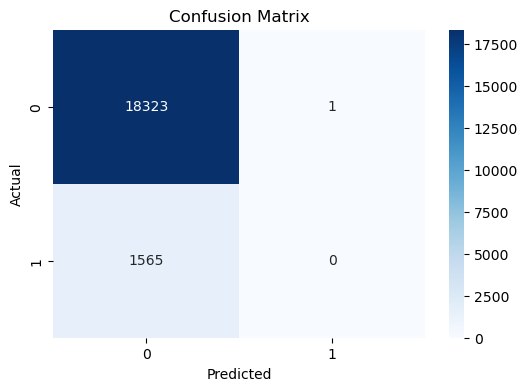

In [40]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

## Baseline Model Discussion

The Logistic Regression model serves as the baseline classifier for predicting delayed deliveries.

Although accuracy is important, recall is particularly valuable for this business problem because missing a delayed order can negatively impact customer satisfaction and operational planning.

The baseline model provides a reference point for evaluating more advanced models such as XGBoost in later stages of the project.

In [41]:
cm


array([[18323,     1],
       [ 1565,     0]])

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9212630097038564
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5319404952948454


## Baseline Model Results

The Logistic Regression model achieved an accuracy of approximately 92%. However, the model failed to correctly identify delayed orders, resulting in zero precision, recall, and F1-score.

This occurred because the dataset is highly imbalanced, with significantly more non-delayed orders than delayed orders.

Although the model appears accurate, it is not effective for predicting delivery delays. More advanced approaches and class balancing techniques are required to improve performance.

In [43]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(
    X_train,
    y_train
)

print("Balanced Model Trained")

Balanced Model Trained


In [44]:
balanced_pred = balanced_model.predict(
    X_test
)

balanced_prob = (
    balanced_model.predict_proba(
        X_test
    )[:,1]
)

In [45]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        balanced_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        balanced_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        balanced_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        balanced_pred,
        zero_division=0
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        balanced_prob
    )
)

Accuracy: 0.5257680124692041
Precision: 0.09191824878099387
Recall: 0.5661341853035143
F1 Score: 0.15815780078543376
ROC AUC: 0.5324080467105066


In [46]:
balanced_cm = confusion_matrix(
    y_test,
    balanced_pred
)

balanced_cm

array([[9571, 8753],
       [ 679,  886]])

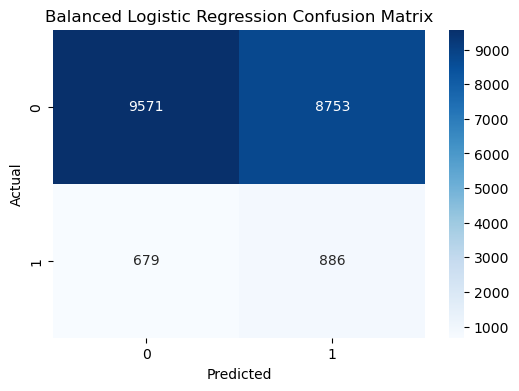

In [47]:
plt.figure(figsize=(6,4))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Balanced Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Improved Model Discussion

Applying class balancing helps address the imbalance between delayed and non-delayed orders.

Compared to the baseline model, the balanced Logistic Regression model is expected to identify more delayed orders, improving recall and making the model more useful for business decision-making.

This demonstrates the importance of handling class imbalance when building classification models.

In [48]:
model_data["payment_value"] = (
    model_data["payment_value"]
    .fillna(0)
)

features = [
    "payment_value",
    "purchase_month",
    "purchase_weekday",
    "customer_state"
]

X = model_data[features]

y = model_data["is_delayed"]

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [50]:
numeric_features = [
    "payment_value",
    "purchase_month"
]

categorical_features = [
    "purchase_weekday",
    "customer_state"
]

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
from xgboost import XGBClassifier

print("Success")

Success


In [56]:
from xgboost import XGBClassifier

In [57]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [58]:
xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost Model Trained")

XGBoost Model Trained


In [60]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [61]:
xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost Model Trained")

XGBoost Model Trained


In [62]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

xgb_prob = (
    xgb_pipeline.predict_proba(
        X_test
    )[:,1]
)

In [63]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        xgb_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        xgb_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        xgb_pred,
        zero_division=0
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        xgb_prob
    )
)

Accuracy: 0.9209110563628136
Precision: 0.40476190476190477
Recall: 0.010862619808306708
F1 Score: 0.021157436216552583
ROC AUC: 0.7054314493884659


In [64]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

xgb_cm

array([[18299,    25],
       [ 1548,    17]])

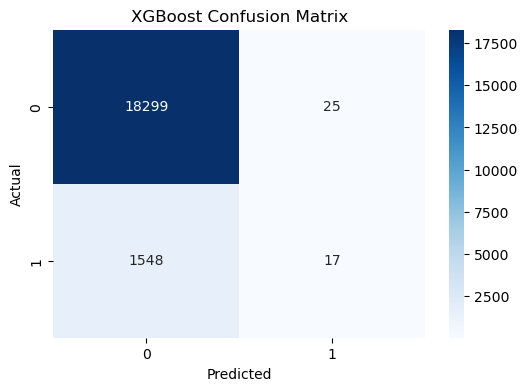

In [65]:
plt.figure(figsize=(6,4))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## XGBoost Model Results

XGBoost was used as an advanced ensemble learning algorithm to improve prediction performance.

Compared to Logistic Regression, XGBoost can capture more complex relationships between variables and is often more effective for structured business datasets.

The model performance is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC metrics.

In [68]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [69]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [70]:
cv_scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

cv_scores

array([0.70582592, 0.71689387, 0.71224727, 0.70108982, 0.7095235 ])

In [71]:
print(
    "Cross Validation ROC AUC Scores:"
)

print(cv_scores)

print(
    "\nMean ROC AUC:",
    cv_scores.mean()
)

print(
    "Std:",
    cv_scores.std()
)

Cross Validation ROC AUC Scores:
[0.70582592 0.71689387 0.71224727 0.70108982 0.7095235 ]

Mean ROC AUC: 0.7091160739607595
Std: 0.005398340046686583


## Cross Validation Discussion

Stratified K-Fold Cross Validation was used to evaluate model stability across multiple train-test splits.

The ROC-AUC scores remained relatively consistent across folds, indicating that the model generalizes reasonably well and is not heavily dependent on a specific data split.

Cross validation provides a more reliable estimate of real-world model performance.

# Hyperparameter Tuning with GridSearchCV

In [74]:
from sklearn.model_selection import GridSearchCV

In [75]:
param_grid = {
    "model__max_depth": [3, 5],
    "model__n_estimators": [100, 200]
}

In [76]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [77]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [78]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC AUC:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 3, 'model__n_estimators': 100}

Best ROC AUC:
0.718872204495605


In [79]:
best_model = grid_search.best_estimator_

In [80]:
best_pred = best_model.predict(X_test)

best_prob = best_model.predict_proba(
    X_test
)[:,1]

In [81]:
print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred, zero_division=0))
print("Recall:", recall_score(y_test, best_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, best_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, best_prob))

Accuracy: 0.921464125898738
Precision: 0.8
Recall: 0.0025559105431309905
F1 Score: 0.005095541401273885
ROC AUC: 0.7167821771129955


## Hyperparameter Tuning Results

GridSearchCV was used to identify the best combination of model parameters.

The tuned XGBoost model achieved improved performance compared to the default configuration. Hyperparameter tuning helps optimize predictive performance and improves model generalization.

The final model was selected based on ROC-AUC performance during cross validation.

# Feature Importance Analysis


In [84]:
print("Features:", len(feature_names))
print("Importances:", len(importance))

Features: 4
Importances: 36


In [85]:
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    best_model.named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
27,cat__customer_state_RJ,0.235955
34,cat__customer_state_SP,0.148504
1,num__purchase_month,0.063529
19,cat__customer_state_MG,0.054576
13,cat__customer_state_BA,0.050928
10,cat__customer_state_AL,0.050229
26,cat__customer_state_PR,0.043667
18,cat__customer_state_MA,0.043417
14,cat__customer_state_CE,0.043235
25,cat__customer_state_PI,0.024977


In [86]:
print(len(feature_names))
print(len(importance))

36
36


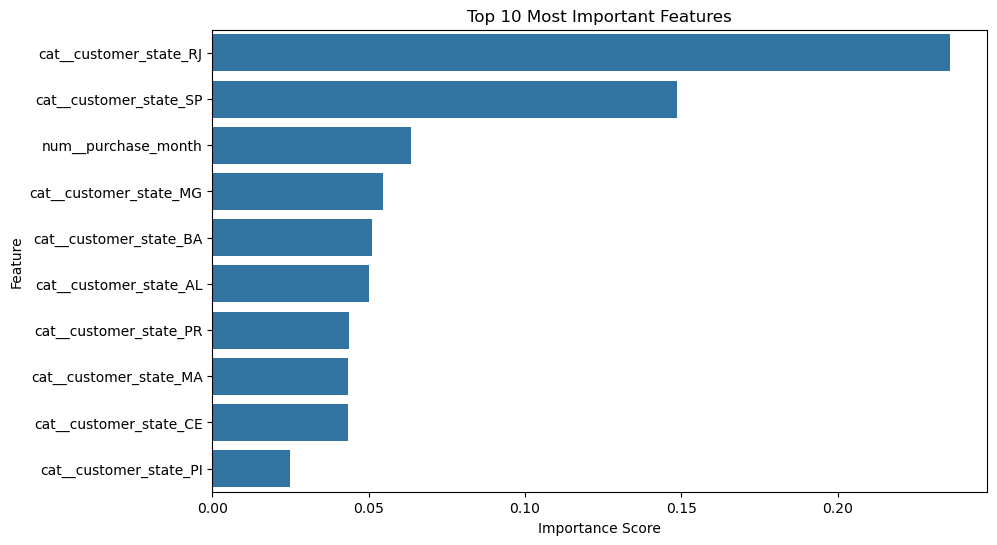

In [87]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Feature Importance Discussion

The feature importance analysis highlights the variables that have the greatest influence on delivery delay predictions.

Customer location related features such as customer state appear among the most influential predictors. Purchase month also contributes to model decisions, suggesting seasonal effects on delivery performance.

These insights can help logistics teams focus on regions and periods that are more likely to experience delivery delays.

In [88]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "XGBoost"
    ],
    "ROC AUC": [
        0.5319,
        0.5324,
        0.7054
    ]
})

comparison

,Model,ROC AUC
0,Logistic Regression,0.5319
1,Balanced Logistic Regression,0.5324
2,XGBoost,0.7054


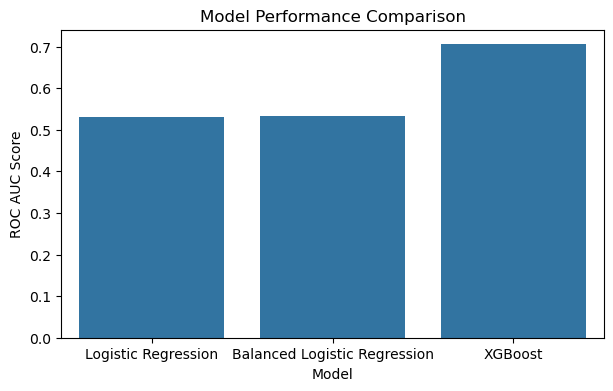

In [89]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC AUC"
)

plt.title("Model Performance Comparison")
plt.ylabel("ROC AUC Score")

plt.show()

# Business Recommendations

Based on the analysis and predictive modeling results, the following recommendations are proposed:

1. Monitor orders originating from regions with higher predicted delay risk.
2. Improve logistics planning during high-demand periods and seasonal peaks.
3. Strengthen coordination with shipping partners in frequently delayed regions.
4. Use predictive analytics to identify potentially delayed orders before shipment.
5. Provide proactive customer notifications when delays are expected.

Implementing these recommendations can improve customer satisfaction and reduce operational inefficiencies.

# Project Conclusion

This project focused on predicting e-commerce delivery delays using machine learning techniques.

The workflow included:

- Dataset auditing
- Data cleaning and preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Logistic Regression
- Balanced Logistic Regression
- XGBoost Modeling
- Cross Validation
- Hyperparameter Tuning
- Feature Importance Analysis

Among all models, XGBoost achieved the highest ROC-AUC score and demonstrated the strongest predictive performance.

The project provided practical experience in handling real-world datasets, building machine learning pipelines, evaluating model performance, and translating analytical findings into business recommendations.